<a href="https://colab.research.google.com/github/arashmhmdi/EV_charging/blob/Arash/notebooks/evchargingpredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Load dataset and inspect basic structure
import pandas as pd

file_path = '/content/drive/MyDrive/x1.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.info())

df.head()

Shape: (1003847, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003847 entries, 0 to 1003846
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   connectionTime_decimal  50000 non-null  float64
 1   chargingDuration        50000 non-null  float64
 2   kWhDelivered            50000 non-null  float64
 3   dayIndicator            50000 non-null  float64
dtypes: float64(4)
memory usage: 30.6 MB
None


,connectionTime_decimal,chargingDuration,kWhDelivered,dayIndicator
0,15.332910,2.301191,11.469551,1.0
1,16.811495,4.941774,3.611695,1.0
2,21.151696,3.567173,14.455706,1.0
3,14.988554,3.089371,5.985330,1.0
4,15.078276,0.145047,1.274458,1.0


Descriptive statistics:
       connectionTime_decimal  chargingDuration  kWhDelivered  dayIndicator
count            50000.000000      50000.000000  50000.000000  50000.000000
mean                14.512928          3.788342      9.441049    378.744500
std                  6.410913          3.343539      5.699289    217.554073
min                  0.001086          0.000821      0.088567      1.000000
25%                 14.291183          1.450014      4.878946    186.000000
50%                 16.171761          2.542454      9.150809    382.000000
75%                 18.072485          5.415204     13.566864    566.000000
max                 23.996749         35.194974     56.453131    752.000000

Missing values per column:
connectionTime_decimal    953847
chargingDuration          953847
kWhDelivered              953847
dayIndicator              953847
dtype: int64


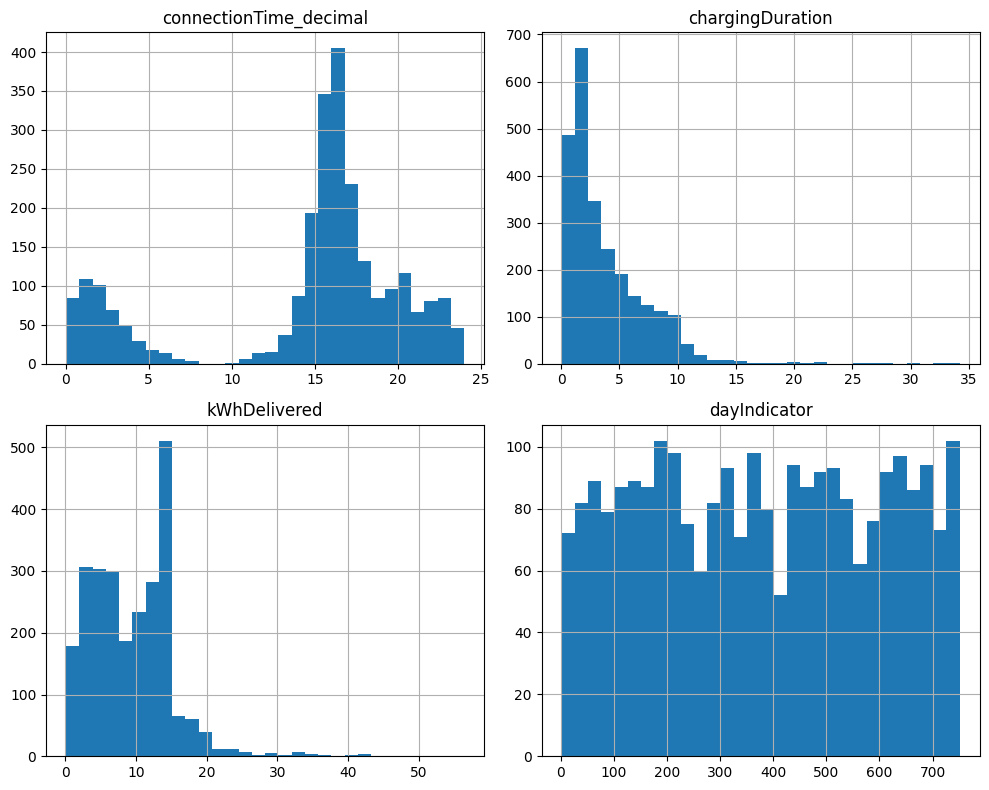

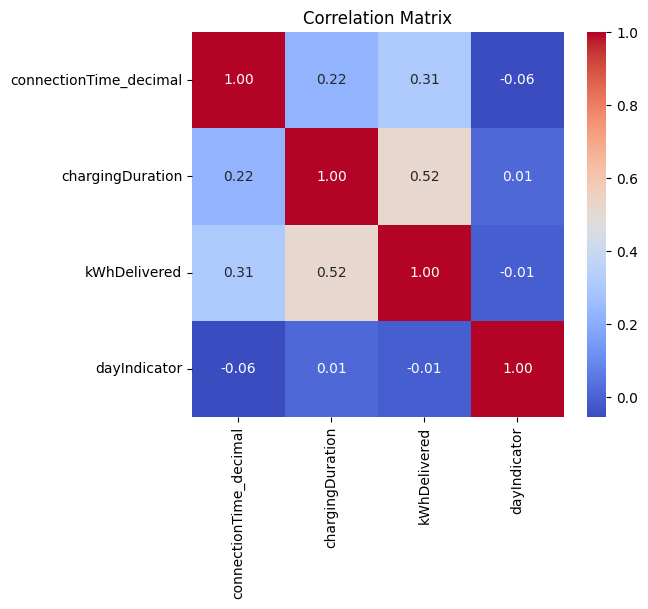

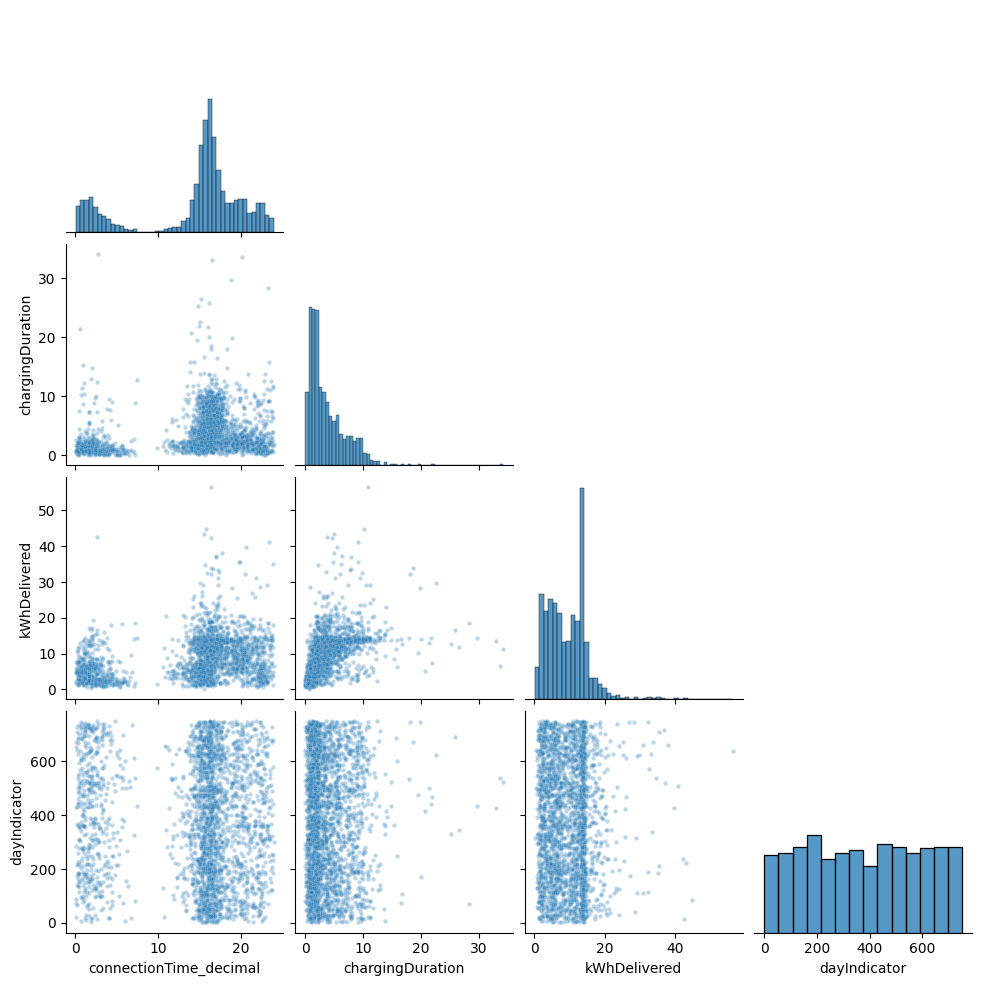

In [2]:
# Step 2: Statistical summary and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descriptive statistics on full dataset
print("Descriptive statistics:")
print(df.describe())

# 2. Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# For plotting, take a random 50k-row sample to speed up rendering
df_small = df.sample(n=50000, random_state=42)

# 3. Histograms for each numeric feature
df_small.hist(bins=30, figsize=(10, 8))
plt.tight_layout()
plt.show()

# 4. Correlation matrix and heatmap
corr = df_small.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 5. Pairplot (sampling further if needed)
sns.pairplot(df_small, corner=True, plot_kws={'alpha':0.3, 's':10})
plt.show()

In [3]:
# Step 3: Data cleaning and feature engineering
import pandas as pd

# 1. Drop rows with any missing values
df_clean = df.dropna().reset_index(drop=True)

# 2. Extract hour and minute from decimal connection time
df_clean['connection_hour'] = df_clean['connectionTime_decimal'].astype(int)
df_clean['connection_minute'] = (
    (df_clean['connectionTime_decimal'] - df_clean['connection_hour']) * 60
).round().astype(int)

# 3. Create charge rate feature (kWh per hour)
df_clean['charge_rate_kwh_per_hour'] = (
    df_clean['kWhDelivered'] / df_clean['chargingDuration']
)

# 4. Extract weekday from day indicator (0=Sunday, ..., 6=Saturday)
df_clean['weekday'] = (df_clean['dayIndicator'] % 7).astype(int)

# 5. Review the new DataFrame structure
print("Shape after cleaning:", df_clean.shape)
print(df_clean[['connection_hour','connection_minute','charge_rate_kwh_per_hour','weekday']].head())

Shape after cleaning: (50000, 8)
   connection_hour  connection_minute  charge_rate_kwh_per_hour  weekday
0               15                 20                  4.984180        1
1               16                 49                  0.730850        1
2               21                  9                  4.052426        1
3               14                 59                  1.937394        1
4               15                  5                  8.786532        1


In [4]:
# Step 4: Baseline modeling with Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define feature matrix X and target vector y
X = df_clean[['connection_hour', 'connection_minute', 'charge_rate_kwh_per_hour', 'weekday']]
y = df_clean['kWhDelivered']

# 2. Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Instantiate and fit the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# 4. Predict on test set and evaluate
y_pred = lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Linear Regression MAE:", mae)
print("Linear Regression R2 :", r2)

Linear Regression MAE: 4.227269584873982
Linear Regression R2 : 0.08406914277874111


In [5]:
# Step 5: Advanced modeling with Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Instantiate RandomForest with manual tuning
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# 2. Fit on training data
rf.fit(X_train, y_train)

# 3. Predict on test set
y_pred_rf = rf.predict(X_test)

# 4. Evaluate performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2 :", r2_rf)

Random Forest MAE: 3.6721993986010726
Random Forest R2 : 0.20165903128700502


Feature importances:
charge_rate_kwh_per_hour    0.460463
connection_hour             0.278756
connection_minute           0.180216
weekday                     0.080565
dtype: float64


/tmp/ipython-input-6-504985381.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


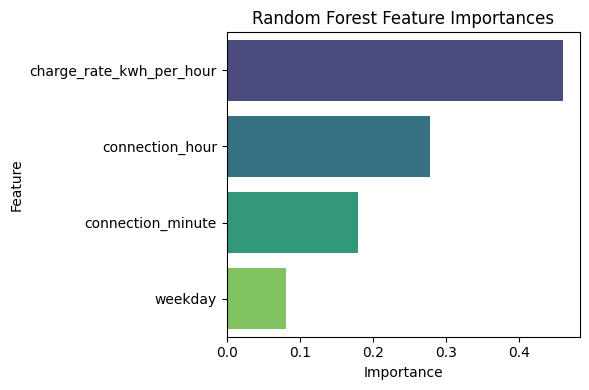

In [6]:
# Step 6: Feature importance extraction and plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importances from the trained Random Forest
importances = rf.feature_importances_
feature_names = X_train.columns

# 2. Build a sorted Series for easy plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 3. Print the importances
print("Feature importances:")
print(feat_imp)

# 4. Plot importances as a horizontal bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [7]:
# Step 7: Hyperparameter tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import randint

# Define parameter distributions
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5)
}

# Initialize RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,              # test 10 random combinations
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=2
)

# Fit on training data
rand_search.fit(X_train, y_train)

# Best parameters and CV score
print("Best parameters:", rand_search.best_params_)
print("Best CV MAE:", -rand_search.best_score_)

# Evaluate on test set
best_rf = rand_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R2 :", r2_score(y_test, y_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=9, n_estimators=70; total time=   3.9s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=9, n_estimators=70; total time=   5.5s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=9, n_estimators=70; total time=   4.1s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=4, n_estimators=124; total time=   8.1s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=4, n_estimators=124; total time=   9.0s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=4, n_estimators=124; total time=   9.4s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=6, n_estimators=149; total time=   8.4s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=6, n_estimators=149; total time=  10.3s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=6, n_estimators=149; total time=  11.1s
[CV] END max_depth=30, min_sample

Linear Regression Test MAE: 4.227, R2: 0.084
Random Forest   Test MAE: 3.531, R2: 0.256


/tmp/ipython-input-8-2488982272.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=metrics, ax=axes[0], palette='pastel')
/tmp/ipython-input-8-2488982272.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=metrics, ax=axes[1], palette='muted')


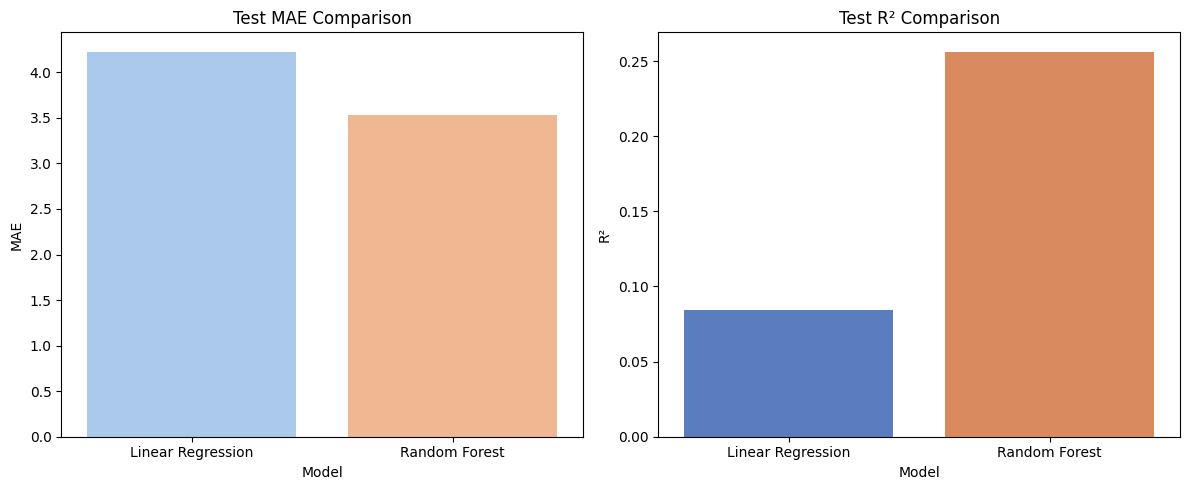

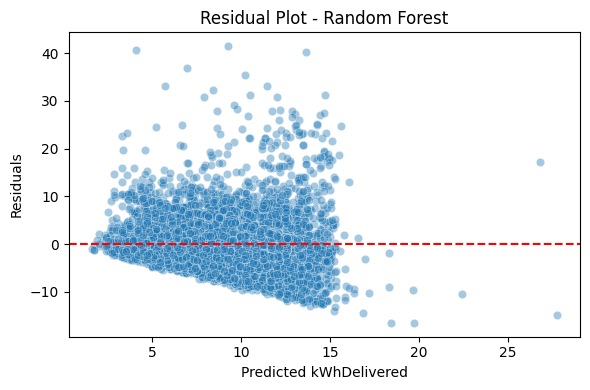

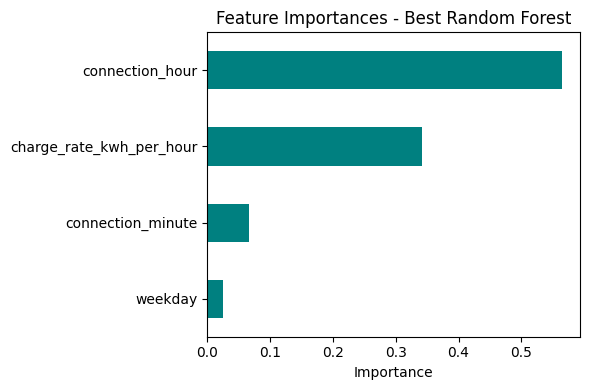

In [8]:
# Step 8: Final evaluation and comprehensive visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Make predictions
y_pred_lr       = lr.predict(X_test)
y_pred_rf_best  = best_rf.predict(X_test)

# 2. Compute metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

mae_rf = mean_absolute_error(y_test, y_pred_rf_best)
r2_rf  = r2_score(y_test, y_pred_rf_best)

print(f"Linear Regression Test MAE: {mae_lr:.3f}, R2: {r2_lr:.3f}")
print(f"Random Forest   Test MAE: {mae_rf:.3f}, R2: {r2_rf:.3f}")

# 3. Bar chart for MAE and R² comparison
metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE'  : [mae_lr, mae_rf],
    'R2'   : [r2_lr, r2_rf]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Model', y='MAE', data=metrics, ax=axes[0], palette='pastel')
axes[0].set_title('Test MAE Comparison')
axes[0].set_ylabel('MAE')

sns.barplot(x='Model', y='R2', data=metrics, ax=axes[1], palette='muted')
axes[1].set_title('Test R² Comparison')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

# 4. Residual plot for Random Forest
residuals_rf = y_test - y_pred_rf_best
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_rf_best, y=residuals_rf, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted kWhDelivered')
plt.ylabel('Residuals')
plt.title('Residual Plot - Random Forest')
plt.tight_layout()
plt.show()

# 5. Final feature importance plot
feat_imp_best = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp_best.sort_values()

plt.figure(figsize=(6, 4))
feat_imp_sorted.plot(kind='barh', color='teal')
plt.title('Feature Importances - Best Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [9]:
import joblib

# Save best Random Forest model
model_path = '/content/drive/MyDrive/best_rf_model.joblib'
joblib.dump(best_rf, model_path)
print('Model saved to:', model_path)

Model saved to: /content/drive/MyDrive/best_rf_model.joblib
